In [1]:
import scanpy as sc
import pandas as pd
import decoupler as dc
import seaborn as sns
import matplotlib.pyplot as plt
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from itertools import combinations
import os

In [2]:
# cwd = os.getcwd()
sample_pbulk = sc.read('../results/Bridge_RNA_adata_merged_harmony_processed_sample_PSEUDOBULK.h5ad')


In [3]:
sample_pbulk.obs['dataset']

101_CASTJ_10M_21    Stanford_10x_Multiome
102_CASTJ_10F_21    Stanford_10x_Multiome
104_CASTJ_10F_21    Stanford_10x_Multiome
113_B6J_10M_21      Stanford_10x_Multiome
114_B6J_10F_21      Stanford_10x_Multiome
115_B6J_10M_21      Stanford_10x_Multiome
116_B6J_10F_21      Stanford_10x_Multiome
769_B6J_10M_21      Stanford_10x_Multiome
775_CASTJ_10M_21    Stanford_10x_Multiome
118_B6J_10F_21        UCI_Parse_Split-seq
117_B6J_10M_21        UCI_Parse_Split-seq
108_CASTJ_10F_21      UCI_Parse_Split-seq
107_CASTJ_10M_21      UCI_Parse_Split-seq
120_B6J_10F_21        UCI_Parse_Split-seq
119_B6J_10M_21        UCI_Parse_Split-seq
106_CASTJ_10F_21      UCI_Parse_Split-seq
105_CASTJ_10M_21      UCI_Parse_Split-seq
768_B6J_10F_21            Broad_SHARE-seq
773_CASTJ_10M_21          Broad_SHARE-seq
771_B6J_10M_21            Broad_SHARE-seq
770_CASTJ_10F_21          Broad_SHARE-seq
772_CASTJ_10F_21          Broad_SHARE-seq
767_B6J_10M_21            Broad_SHARE-seq
766_B6J_10F_21            Broad_SH

In [59]:
sample_pbulk = sc.read('../results/Bridge_RNA_adata_merged_harmony_processed_sample_PSEUDOBULK.h5ad')
# dea_results = []
# datasets = sample_pbulk.obs['dataset'].unique().tolist()
# dataset_combinations = list(combinations(datasets, 2))
# for dataset1, dataset2 in dataset_combinations:
#     filtering = [dataset1, dataset2]

#     # boolean mask over observations
#     mask = sample_pbulk.obs['dataset'].isin(filtering).values

#     # subset AnnData by obs
#     adatac = sample_pbulk[mask].copy()

#     dds = DeseqDataSet(
#             adata=adatac,
#             design_factors="dataset",
#             ref_level=["dataset", dataset2],  
#             refit_cooks=True,
#             n_cpus=None,
#             quiet=True
#         )

#     dds.deseq2()

#     stat_res = DeseqStats(dds, contrast=["dataset", dataset1, dataset2])

#     stat_res.summary()

#     coeff_name = "dataset" + '_' + dataset1 + '_vs_' + dataset2
#     # stat_res.lfc_shrink(coeff=coeff_name)



#     out_df = stat_res.results_df
#     out_df['dataset1'] = dataset1
#     out_df['dataset2'] = dataset2
    
#     dea_results.append(out_df)

    

In [5]:
# degs.to_csv('dataset_total_expression_degs.csv')

# volcano plots

In [6]:
degs = pd.read_csv('dataset_total_expression_degs.csv')

In [7]:
degs

,gene_name_unique,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,dataset1,dataset2
0,Gm23910,0.000000,NaN,NaN,NaN,NaN,NaN,Stanford_10x_Multiome,UCI_Parse_Split-seq
1,Alg12,730.010673,-0.363069,0.099481,-3.649633,2.626156e-04,6.861402e-04,Stanford_10x_Multiome,UCI_Parse_Split-seq
2,ENSMUSG00000125760,0.952872,-0.320704,0.888875,-0.360798,7.182507e-01,7.792323e-01,Stanford_10x_Multiome,UCI_Parse_Split-seq
3,Rpl28-ps2,1.002125,0.603966,1.328993,0.454454,6.495024e-01,7.206994e-01,Stanford_10x_Multiome,UCI_Parse_Split-seq
4,Gm25687,0.000000,NaN,NaN,NaN,NaN,NaN,Stanford_10x_Multiome,UCI_Parse_Split-seq
...,...,...,...,...,...,...,...,...,...
469783,ENSMUSG00000127138,5.396609,-2.441386,0.487183,-5.011234,5.408198e-07,5.974251e-06,Broad_SHARE-seq,UCI_SHARE-seq
469784,Mmrn2,6.836562,0.750964,0.479427,1.566378,1.172601e-01,2.408402e-01,Broad_SHARE-seq,UCI_SHARE-seq
469785,Anapc1,1318.175823,0.275432,0.048906,5.631899,1.782361e-08,2.574077e-07,Broad_SHARE-seq,UCI_SHARE-seq
469786,Gm13144,0.000000,NaN,NaN,NaN,NaN,NaN,Broad_SHARE-seq,UCI_SHARE-seq


In [8]:
degs['comparison'] = degs['dataset1'].astype(str) + '_vs_' + degs['dataset2'].astype(str)

In [9]:
degs_sig = degs[(degs['padj'] < 0.05) & (abs(degs['log2FoldChange'])>1)]

In [10]:
degs_sig['comparison'].value_counts()

comparison
Stanford_10x_Multiome_vs_Broad_SHARE-seq        22746
Stanford_10x_Multiome_vs_UCI_Parse_Split-seq    20105
Stanford_10x_Multiome_vs_UCI_SHARE-seq          16346
UCI_Parse_Split-seq_vs_Broad_SHARE-seq          14765
UCI_Parse_Split-seq_vs_UCI_SHARE-seq             6772
Broad_SHARE-seq_vs_UCI_SHARE-seq                 3204
Name: count, dtype: int64

In [11]:
# Volcano plots per comparison in a single DataFrame `degs`
# Assumes `degs` has columns:
# ['baseMean','log2FoldChange','lfcSE','stat','pvalue','padj','dataset1','dataset2']
# and the index is gene IDs / names (used for optional annotations).

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def make_volcanoes(
    degs: pd.DataFrame,
    alpha: float = 0.05,
    lfc_thresh: float = 1.0,
    outdir: str | None = None,
    annotate_top: int = 0,  # set >0 to label top-N significant genes by padj
    point_size: int = 10
) -> pd.DataFrame:
    """
    Create volcano plots for each (dataset1, dataset2) comparison in `degs`.
    Prints the number of DEGs (padj<alpha & |log2FC|>lfc_thresh) per comparison.
    Optionally saves figures to `outdir` and returns a summary DataFrame.
    """
    required = {"log2FoldChange", "pvalue", "padj", "dataset1", "dataset2"}
    missing = required - set(degs.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    if outdir:
        os.makedirs(outdir, exist_ok=True)

    def _safe_name(s: str) -> str:
        return re.sub(r"\W+", "_", s)

    summary_rows = []
    for (d1, d2), group in degs.groupby(["dataset1", "dataset2"], dropna=False):
        # Drop rows that can't be plotted
        g = group.dropna(subset=["log2FoldChange", "pvalue", "padj"]).copy()
        if g.empty:
            print(f"[WARN] No plottable rows for {d1} vs {d2}")
            summary_rows.append({"dataset1": d1, "dataset2": d2, "n_sig": 0, "n_total": 0})
            continue

        # Avoid -log10(0)
        g["pvalue_clipped"] = g["padj"].clip(lower=1e-300)
        g["neglog10p"] = -np.log10(g["pvalue_clipped"])

        sig_mask = (g["padj"] < alpha) & (g["log2FoldChange"].abs() > lfc_thresh)
        n_sig = int(sig_mask.sum())

        # ---- Plot ----
        plt.figure(figsize=(7, 6))
        # All points
        plt.scatter(
            g["log2FoldChange"], g["neglog10p"],
            s=point_size, alpha=0.6, edgecolor="none"
        )
        # Significant points overlay
        if n_sig > 0:
            plt.scatter(
                g.loc[sig_mask, "log2FoldChange"],
                g.loc[sig_mask, "neglog10p"],
                s=point_size + 6, alpha=0.8, edgecolor="none"
            )

        # Threshold lines
        plt.axhline(-np.log10(alpha), linestyle="--", linewidth=1)
        plt.axvline(-lfc_thresh, linestyle="--", linewidth=1)
        plt.axvline(lfc_thresh, linestyle="--", linewidth=1)

        title = f"Volcano: {d1} vs {d2} | DEGs={n_sig} (padj<{alpha}, |LFC|>{lfc_thresh})"
        plt.title(title)
        plt.xlabel("log2 Fold Change")
        plt.ylabel("-log10(p-value)")
        plt.tight_layout()

        # Optional: annotate top-N significant genes by padj
        if annotate_top and n_sig > 0:
            tops = (
                g.loc[sig_mask]
                .sort_values("padj")
                .head(annotate_top)
            )
            for idx, row in tops.iterrows():
                plt.annotate(
                    str(idx),
                    (row["log2FoldChange"], row["neglog10p"]),
                    xytext=(3, 3),
                    textcoords="offset points",
                    fontsize=8
                )

        # Save if requested
        if outdir:
            fname = f"volcano_{_safe_name(str(d1))}_vs_{_safe_name(str(d2))}.png"
            plt.savefig(os.path.join(outdir, fname), dpi=300)
        plt.show()

        # Print + collect summary
        print(f"{d1} vs {d2}: n_sig={n_sig} out of n_total={len(g)}")
        summary_rows.append({"dataset1": d1, "dataset2": d2, "n_sig": n_sig, "n_total": len(g)})

    summary = pd.DataFrame(summary_rows).sort_values(["dataset1", "dataset2"]).reset_index(drop=True)
    return summary

# ---- Usage ----


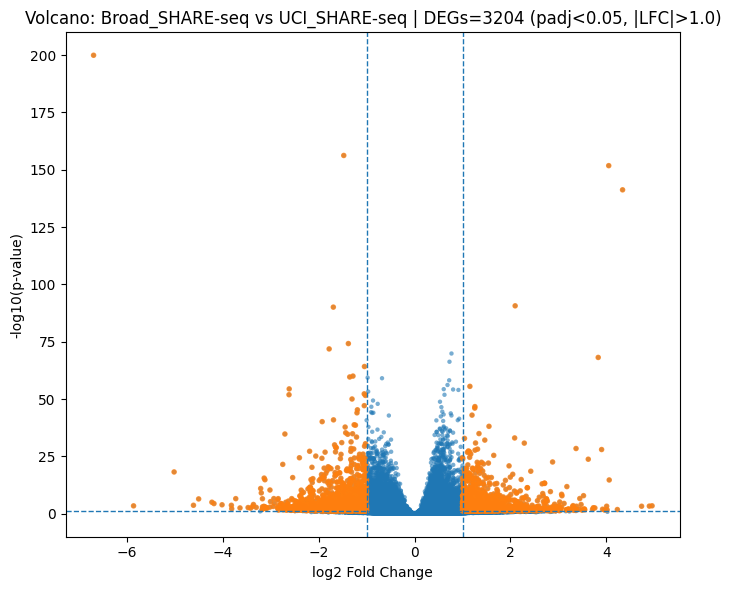

Broad_SHARE-seq vs UCI_SHARE-seq: n_sig=3204 out of n_total=36697


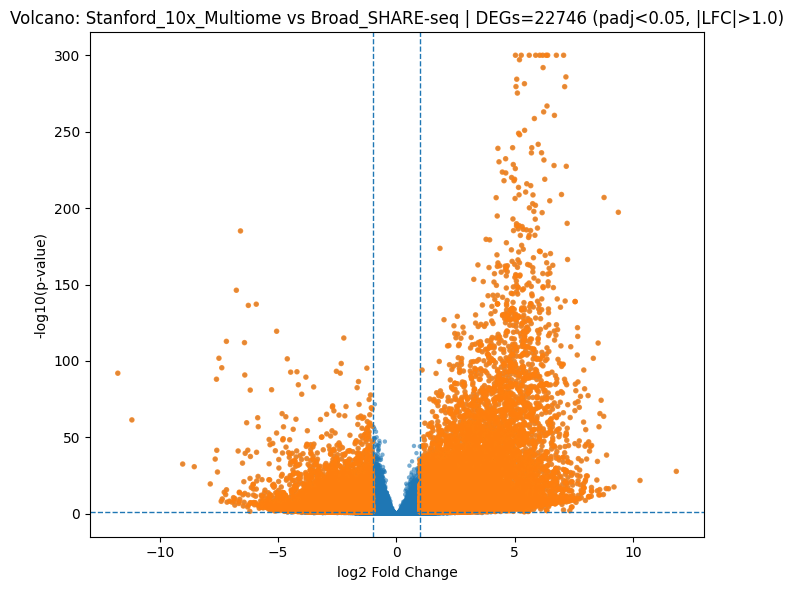

Stanford_10x_Multiome vs Broad_SHARE-seq: n_sig=22746 out of n_total=52761


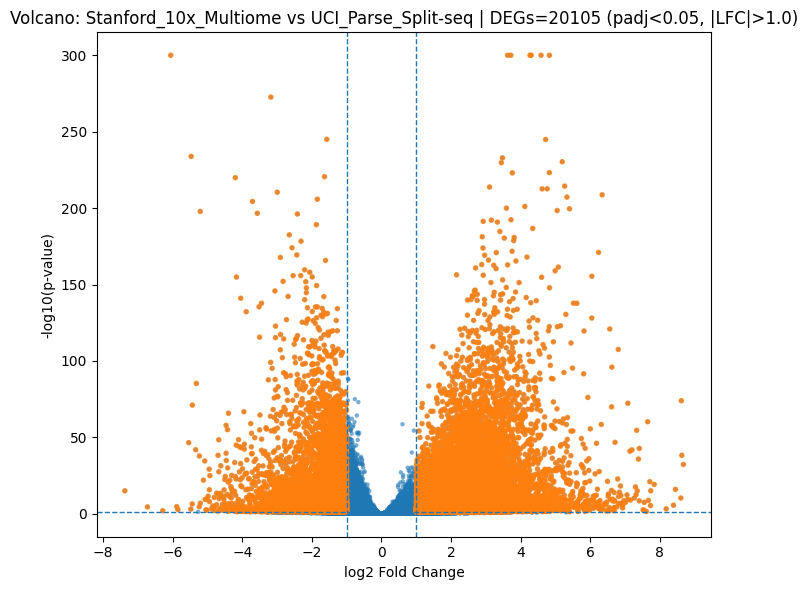

Stanford_10x_Multiome vs UCI_Parse_Split-seq: n_sig=20105 out of n_total=53336


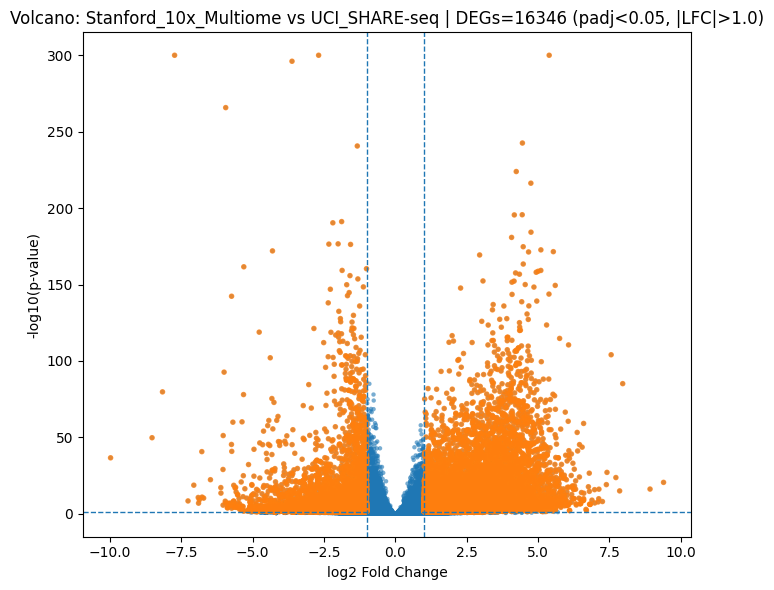

Stanford_10x_Multiome vs UCI_SHARE-seq: n_sig=16346 out of n_total=50172


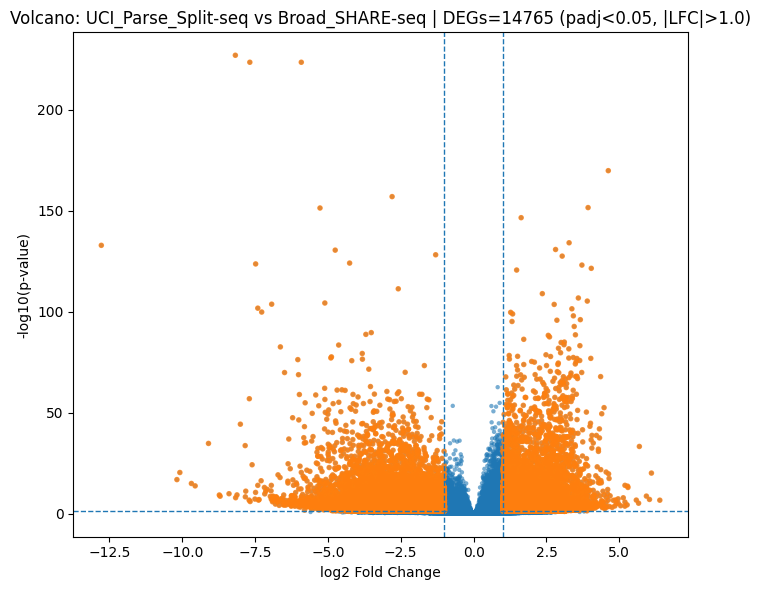

UCI_Parse_Split-seq vs Broad_SHARE-seq: n_sig=14765 out of n_total=50153


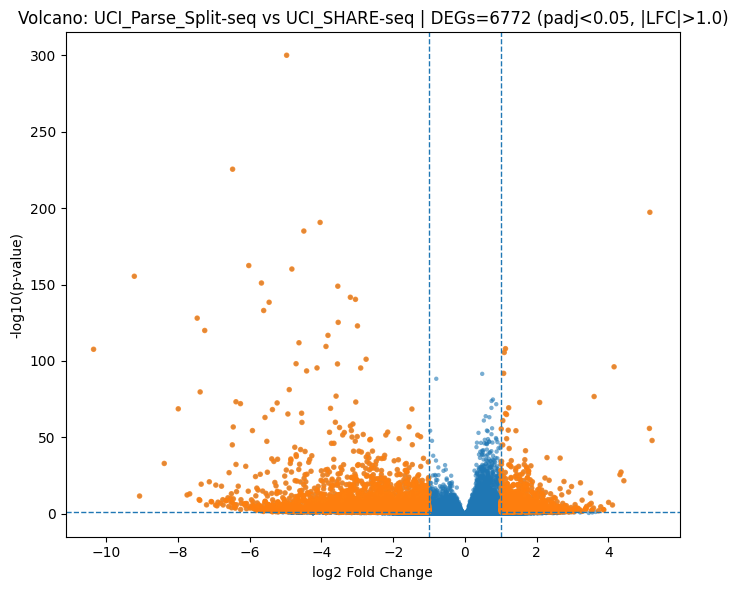

UCI_Parse_Split-seq vs UCI_SHARE-seq: n_sig=6772 out of n_total=45674
                dataset1             dataset2  n_sig  n_total
0        Broad_SHARE-seq        UCI_SHARE-seq   3204    36697
1  Stanford_10x_Multiome      Broad_SHARE-seq  22746    52761
2  Stanford_10x_Multiome  UCI_Parse_Split-seq  20105    53336
3  Stanford_10x_Multiome        UCI_SHARE-seq  16346    50172
4    UCI_Parse_Split-seq      Broad_SHARE-seq  14765    50153
5    UCI_Parse_Split-seq        UCI_SHARE-seq   6772    45674


In [12]:
summary_df = make_volcanoes(degs, alpha=0.05, lfc_thresh=1.0, outdir="volcano_plots", annotate_top=0)
print(summary_df)
# 

In [13]:
degs[['dataset1','dataset2','comparison']].drop_duplicates()

,dataset1,dataset2,comparison
0,Stanford_10x_Multiome,UCI_Parse_Split-seq,Stanford_10x_Multiome_vs_UCI_Parse_Split-seq
78298,Stanford_10x_Multiome,Broad_SHARE-seq,Stanford_10x_Multiome_vs_Broad_SHARE-seq
156596,Stanford_10x_Multiome,UCI_SHARE-seq,Stanford_10x_Multiome_vs_UCI_SHARE-seq
234894,UCI_Parse_Split-seq,Broad_SHARE-seq,UCI_Parse_Split-seq_vs_Broad_SHARE-seq
313192,UCI_Parse_Split-seq,UCI_SHARE-seq,UCI_Parse_Split-seq_vs_UCI_SHARE-seq
391490,Broad_SHARE-seq,UCI_SHARE-seq,Broad_SHARE-seq_vs_UCI_SHARE-seq


In [14]:
degs['comparison'].value_counts()

comparison
Stanford_10x_Multiome_vs_UCI_Parse_Split-seq    78298
Stanford_10x_Multiome_vs_Broad_SHARE-seq        78298
Stanford_10x_Multiome_vs_UCI_SHARE-seq          78298
UCI_Parse_Split-seq_vs_Broad_SHARE-seq          78298
UCI_Parse_Split-seq_vs_UCI_SHARE-seq            78298
Broad_SHARE-seq_vs_UCI_SHARE-seq                78298
Name: count, dtype: int64

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def volcano_multipanel(
    degs,
    alpha: float = 0.05,
    lfc_thresh: float = 1.0,
    point_size: int = 10,
    ncols: int = 3,
    tick_fontsize: int = 14
):
    """
    Make a multi-panel volcano plot for all dataset1 vs dataset2 comparisons
    with shared x/y axis limits.
    """

    comparisons = list(degs.groupby(["dataset1", "dataset2"]))
    nplots = len(comparisons)
    nrows = int(np.ceil(nplots / ncols))

    # =========================================================
    # PRECOMPUTE GLOBAL LIMITS
    # =========================================================
    all_groups = []

    global_xmax = 0
    global_ymax = 0

    for (_, _), group in comparisons:

        g = group.dropna(
            subset=["log2FoldChange", "pvalue", "padj"]
        ).copy()

        if g.empty:
            continue

        g["pvalue_clipped"] = g["pvalue"].clip(lower=1e-300)
        g["neglog10p"] = -np.log10(g["pvalue_clipped"])

        global_xmax = max(
            global_xmax,
            np.abs(g["log2FoldChange"]).max()
        )

        global_ymax = max(
            global_ymax,
            g["neglog10p"].max()
        )

        all_groups.append(g)

    # Add small padding
    global_xmax *= 1.05
    global_ymax *= 1.05

    # =========================================================
    # MAKE FIGURE
    # =========================================================
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(6*ncols, 5*nrows),
        squeeze=False
    )

    axes = axes.flatten()

    for ax, ((d1, d2), group) in zip(axes, comparisons):

        g = group.dropna(
            subset=["log2FoldChange", "pvalue", "padj"]
        ).copy()

        if g.empty:
            ax.set_visible(False)
            continue

        g["pvalue_clipped"] = g["pvalue"].clip(lower=1e-300)
        g["neglog10p"] = -np.log10(g["pvalue_clipped"])

        sig_mask = (
            (g["padj"] < alpha) &
            (g["log2FoldChange"].abs() > lfc_thresh)
        )

        n_sig = int(sig_mask.sum())

        # All points
        ax.scatter(
            g["log2FoldChange"],
            g["neglog10p"],
            c="grey",
            s=point_size,
            alpha=0.6
        )

        # Significant points
        ax.scatter(
            g.loc[sig_mask, "log2FoldChange"],
            g.loc[sig_mask, "neglog10p"],
            c="red",
            s=point_size,
            alpha=0.8
        )

        # Threshold lines
        ax.axhline(
            -np.log10(alpha),
            linestyle="--",
            linewidth=1,
            color="blue"
        )

        ax.axvline(
            -lfc_thresh,
            linestyle="--",
            linewidth=1,
            color="blue"
        )

        ax.axvline(
            lfc_thresh,
            linestyle="--",
            linewidth=1,
            color="blue"
        )

        # =========================================================
        # SHARED LIMITS
        # =========================================================
        ax.set_xlim(-global_xmax, global_xmax)
        ax.set_ylim(0, global_ymax)

        ax.set_title(
            f"{d1} vs {d2}\nDEGs={n_sig}",
            fontsize=18
        )

        ax.set_xlabel(
            "log2 Fold Change",
            fontsize=16
        )

        ax.set_ylabel(
            "-log10(p-value)",
            fontsize=16
        )

        ax.tick_params(
            axis='both',
            labelsize=tick_fontsize
        )

    # Hide unused panels
    for ax in axes[nplots:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

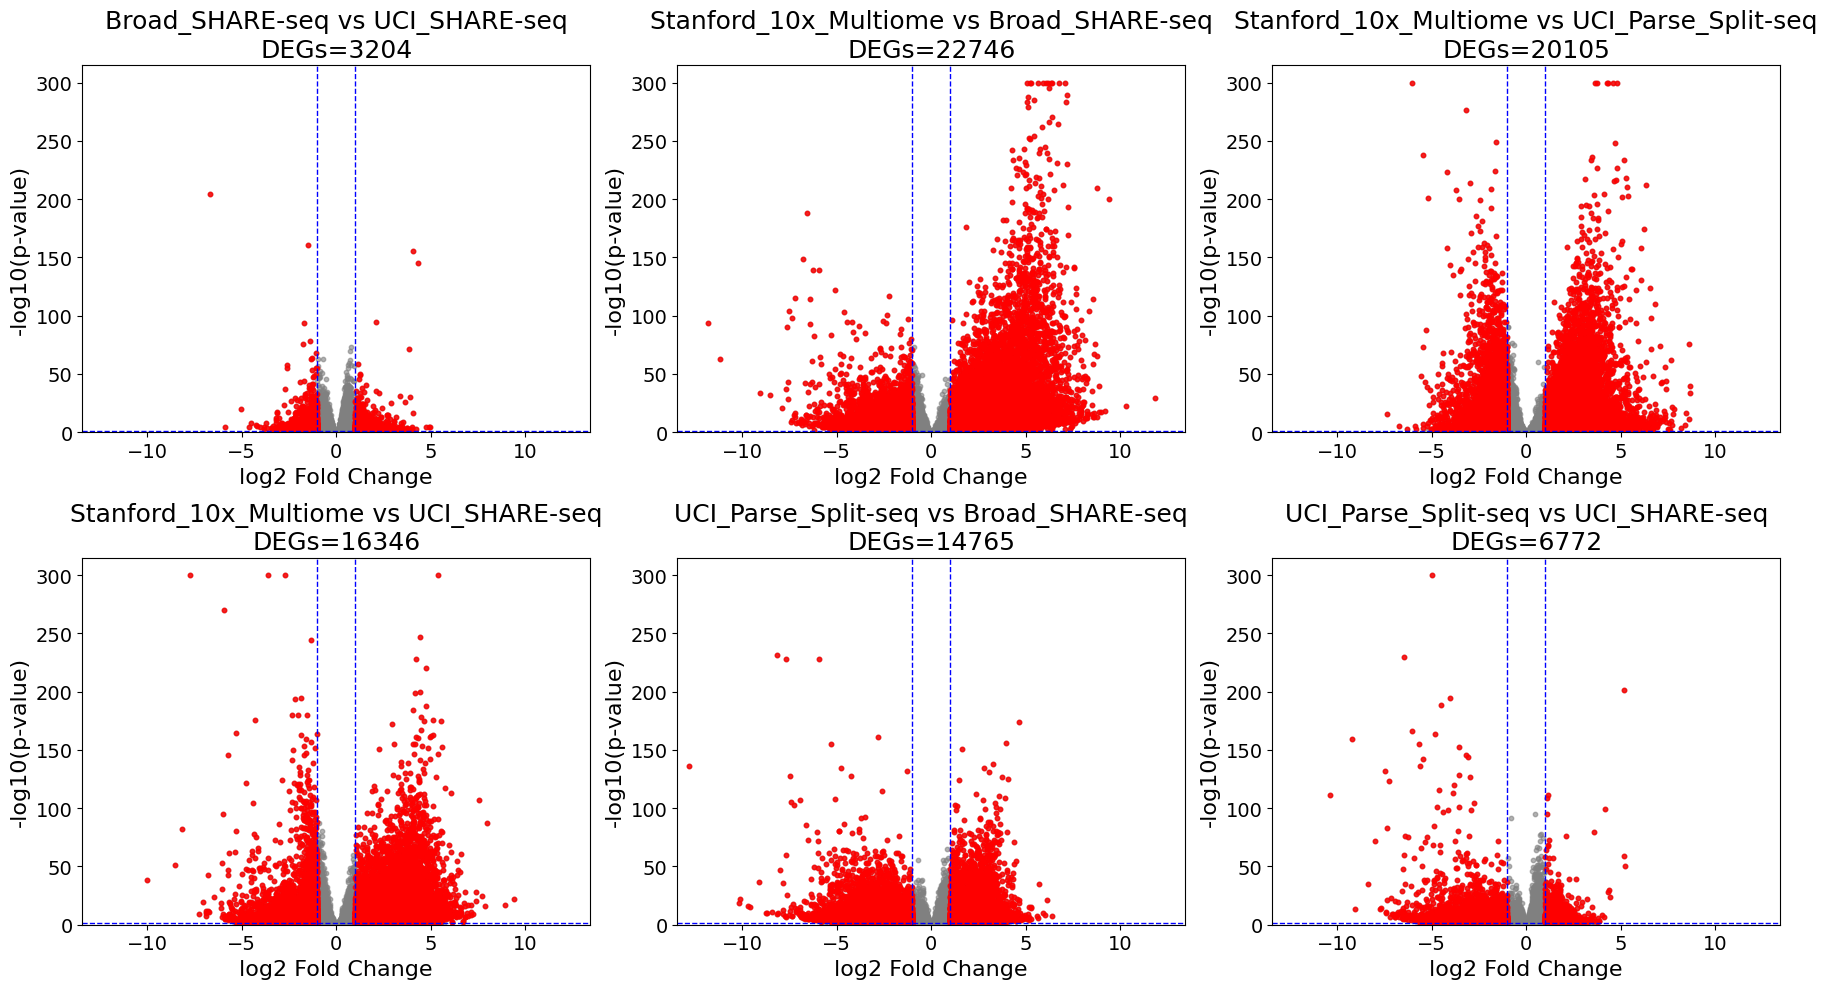

In [16]:
volcano_multipanel(degs, alpha=0.05, lfc_thresh=1.0, ncols=3)


In [17]:
degs[['dataset1','dataset2','comparison']]

,dataset1,dataset2,comparison
0,Stanford_10x_Multiome,UCI_Parse_Split-seq,Stanford_10x_Multiome_vs_UCI_Parse_Split-seq
1,Stanford_10x_Multiome,UCI_Parse_Split-seq,Stanford_10x_Multiome_vs_UCI_Parse_Split-seq
2,Stanford_10x_Multiome,UCI_Parse_Split-seq,Stanford_10x_Multiome_vs_UCI_Parse_Split-seq
3,Stanford_10x_Multiome,UCI_Parse_Split-seq,Stanford_10x_Multiome_vs_UCI_Parse_Split-seq
4,Stanford_10x_Multiome,UCI_Parse_Split-seq,Stanford_10x_Multiome_vs_UCI_Parse_Split-seq
...,...,...,...
469783,Broad_SHARE-seq,UCI_SHARE-seq,Broad_SHARE-seq_vs_UCI_SHARE-seq
469784,Broad_SHARE-seq,UCI_SHARE-seq,Broad_SHARE-seq_vs_UCI_SHARE-seq
469785,Broad_SHARE-seq,UCI_SHARE-seq,Broad_SHARE-seq_vs_UCI_SHARE-seq
469786,Broad_SHARE-seq,UCI_SHARE-seq,Broad_SHARE-seq_vs_UCI_SHARE-seq


In [18]:
rename_dict = {
    "Stanford_10x_Multiome": "10x_Multiome",
    "UCI_Parse_Split-seq": "Parse_Split-seq",
    "Broad_SHARE-seq": "SHARE-seq_B",
    "UCI_SHARE-seq": "SHARE-seq_U",
}

# Rename dataset columns
degs["dataset1"] = degs["dataset1"].replace(rename_dict)
degs["dataset2"] = degs["dataset2"].replace(rename_dict)

# Rename comparison strings
for old, new in rename_dict.items():
    degs["comparison"] = degs["comparison"].str.replace(
        old,
        new,
        regex=False
    )

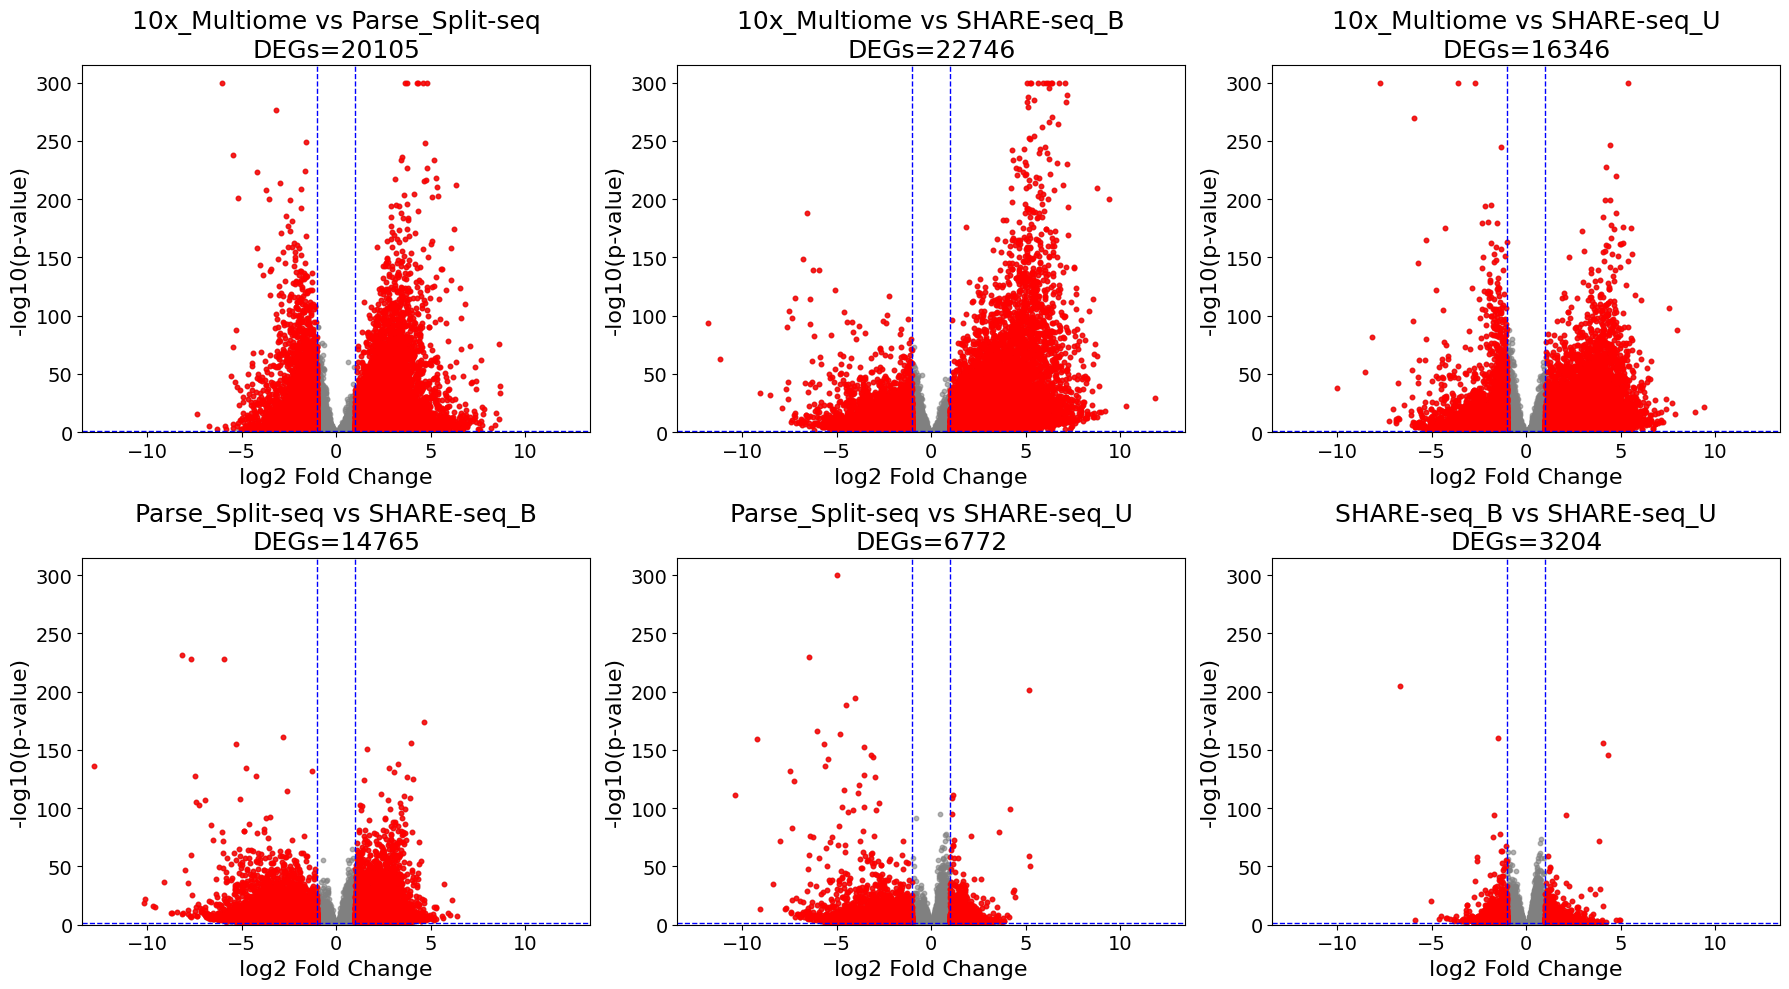

In [19]:
volcano_multipanel(degs, alpha=0.05, lfc_thresh=1.0, ncols=3)


In [20]:
degs['logpadj'] = -np.log10(degs['padj'])

/opt/apps/python/3.10.2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [21]:
degs[degs['comparison'] == 'Stanford_10x_Multiome_vs_Broad_SHARE-seq'].sort_values('logpadj').dropna()

,gene_name_unique,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,dataset1,dataset2,comparison,logpadj


In [22]:
degs['comparison'].value_counts()

comparison
10x_Multiome_vs_Parse_Split-seq    78298
10x_Multiome_vs_SHARE-seq_B        78298
10x_Multiome_vs_SHARE-seq_U        78298
Parse_Split-seq_vs_SHARE-seq_B     78298
Parse_Split-seq_vs_SHARE-seq_U     78298
SHARE-seq_B_vs_SHARE-seq_U         78298
Name: count, dtype: int64

In [23]:
parse_v_10x = degs[degs['comparison'] == 'Stanford_10x_Multiome_vs_UCI_Parse_Split-seq']

In [24]:
parse_v_10x[(abs(parse_v_10x['log2FoldChange']) > 1) & (parse_v_10x['padj'] < 0.05)]

,gene_name_unique,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,dataset1,dataset2,comparison,logpadj


In [25]:
biotype = pd.read_csv('/dfs9/seyedam-lab/weberrl/crsp_weberrl/igvf_genocode_36_biotypes.txt', sep = '\t', header = None)
biotype_map = dict(zip(biotype[0], biotype[1]))

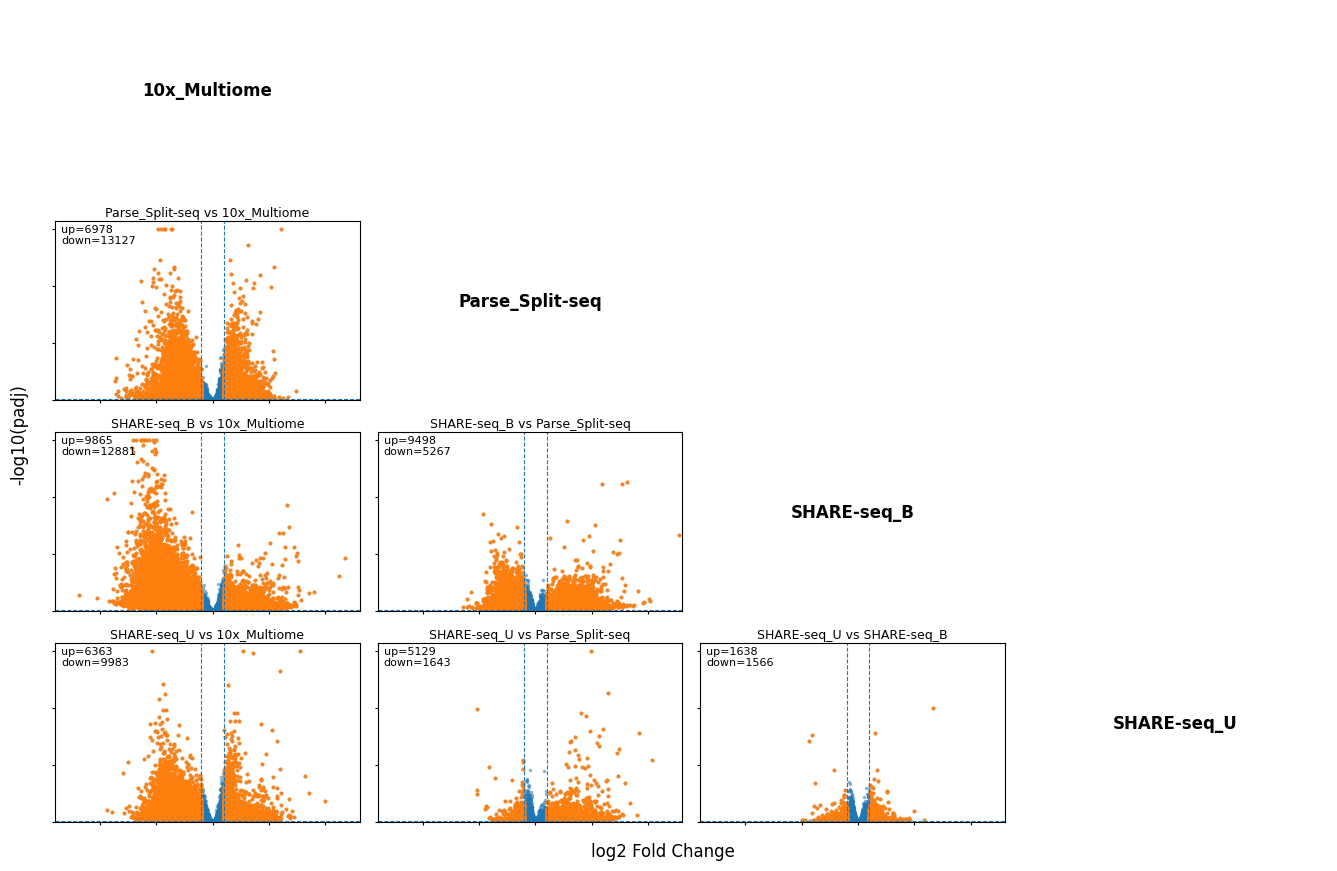

,dataset_row,dataset_col,comparison_found,used_flipped_reverse,n_sig,n_up,n_down,n_total
0,Parse_Split-seq,10x_Multiome,True,True,20105,6978,13127,53336
1,SHARE-seq_B,10x_Multiome,True,True,22746,9865,12881,52761
2,SHARE-seq_B,Parse_Split-seq,True,True,14765,9498,5267,50153
3,SHARE-seq_U,10x_Multiome,True,True,16346,6363,9983,50172
4,SHARE-seq_U,Parse_Split-seq,True,True,6772,5129,1643,45674
5,SHARE-seq_U,SHARE-seq_B,True,True,3204,1638,1566,36697


In [26]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def volcano_pairwise_grid(
    degs: pd.DataFrame,
    *,
    alpha: float = 0.05,
    lfc_thresh: float = 1.0,
    annotate_top: int = 0,
    point_size: int = 6,
    datasets: list[str] | None = None,   # optional explicit ordering
    lower_only: bool = True,             # True = only plot below diagonal
    figsize_per_cell=(3.2, 2.2),         # <-- WIDER cells by default
    outpath: str | None = None,          # e.g. "volcano_plots/volcano_pairwise_grid.png"
    title_fontsize: int = 9,
    count_fontsize: int = 8,
    label_fontsize: int = 12,
) -> pd.DataFrame:
    """
    Pairwise volcano grid: datasets on rows/cols, each off-diagonal cell is a volcano plot.
    Uses lower triangle by default. If only reverse comparison exists, flips log2FC.

    Each volcano panel explicitly states: "row vs col"
    and annotates: n_up / n_down based on (padj<alpha & |LFC|>lfc_thresh).

    Returns a summary table for all ordered pairs (row_dataset vs col_dataset) that were plotted.
    """

    required = {"log2FoldChange", "padj", "dataset1", "dataset2"}
    missing = required - set(degs.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df = degs.copy()

    # --- dataset order ---
    if datasets is None:
        datasets = sorted(pd.unique(pd.concat([df["dataset1"], df["dataset2"]], ignore_index=True)))
    n = len(datasets)

    # --- build lookup for fast retrieval ---
    lookup = {k: g for k, g in df.groupby(["dataset1", "dataset2"], dropna=False)}

    def get_group(d1, d2):
        """
        Return (g, flipped_flag) for comparison d1 vs d2.
        If only d2 vs d1 exists, return flipped version with sign-flipped log2FC.
        """
        g = lookup.get((d1, d2), None)
        if g is not None:
            return g, False

        g_rev = lookup.get((d2, d1), None)
        if g_rev is not None:
            g2 = g_rev.copy()
            g2["log2FoldChange"] = -g2["log2FoldChange"]
            g2["dataset1"] = d1
            g2["dataset2"] = d2
            return g2, True

        return None, False

    # --- global axis limits for comparability ---
    g_all = df.dropna(subset=["log2FoldChange", "padj"]).copy()
    g_all["padj_clipped"] = g_all["padj"].clip(lower=1e-300)
    g_all["neglog10p"] = -np.log10(g_all["padj_clipped"])

    if g_all.empty:
        raise ValueError("No plottable rows: all rows are missing log2FoldChange/padj.")

    x_min, x_max = g_all["log2FoldChange"].min(), g_all["log2FoldChange"].max()
    y_max = g_all["neglog10p"].max()

    xpad = 0.05 * (x_max - x_min if x_max > x_min else 1.0)
    ypad = 0.05 * (y_max if y_max > 0 else 1.0)

    xlim = (x_min - xpad, x_max + xpad)
    ylim = (0, y_max + ypad)

    # --- figure (wider panels) ---
    fig_w = figsize_per_cell[0] * n
    fig_h = figsize_per_cell[1] * n
    fig, axes = plt.subplots(n, n, figsize=(fig_w, fig_h), sharex=True, sharey=True)

    summary_rows = []

    for i, d_row in enumerate(datasets):
        for j, d_col in enumerate(datasets):
            ax = axes[i, j]

            # diagonal: dataset labels
            if i == j:
                ax.axis("off")
                ax.text(
                    0.5, 0.55, str(d_row),
                    ha="center", va="center",
                    fontsize=label_fontsize, fontweight="bold",
                    transform=ax.transAxes
                )
                continue

            # upper triangle behavior
            if lower_only and j > i:
                ax.axis("off")
                continue

            g, flipped = get_group(d_row, d_col)
            if g is None:
                ax.axis("off")
                summary_rows.append({
                    "dataset_row": d_row,
                    "dataset_col": d_col,
                    "comparison_found": False,
                    "used_flipped_reverse": False,
                    "n_sig": 0,
                    "n_up": 0,
                    "n_down": 0,
                    "n_total": 0
                })
                continue

            g = g.dropna(subset=["log2FoldChange", "padj"]).copy()
            if g.empty:
                ax.axis("off")
                summary_rows.append({
                    "dataset_row": d_row,
                    "dataset_col": d_col,
                    "comparison_found": True,
                    "used_flipped_reverse": flipped,
                    "n_sig": 0,
                    "n_up": 0,
                    "n_down": 0,
                    "n_total": 0
                })
                continue

            g["padj_clipped"] = g["padj"].clip(lower=1e-300)
            g["neglog10p"] = -np.log10(g["padj_clipped"])

            sig_mask = (g["padj"] < alpha) & (g["log2FoldChange"].abs() > lfc_thresh)
            up_mask = sig_mask & (g["log2FoldChange"] > 0)
            down_mask = sig_mask & (g["log2FoldChange"] < 0)

            n_sig = int(sig_mask.sum())
            n_up = int(up_mask.sum())
            n_down = int(down_mask.sum())

            # points
            ax.scatter(
                g["log2FoldChange"], g["neglog10p"],
                s=point_size, alpha=0.55, linewidths=0
            )
            if n_sig > 0:
                ax.scatter(
                    g.loc[sig_mask, "log2FoldChange"],
                    g.loc[sig_mask, "neglog10p"],
                    s=point_size + 3, alpha=0.85, linewidths=0
                )

            # thresholds
            ax.axhline(-np.log10(alpha), linestyle="--", linewidth=0.8)
            ax.axvline(-lfc_thresh, linestyle="--", linewidth=0.8)
            ax.axvline( lfc_thresh, linestyle="--", linewidth=0.8)

            # explicit comparison label on each panel
            ax.set_title(f"{d_row} vs {d_col}", fontsize=title_fontsize, pad=3)

            # n_up / n_down annotation inside panel
            ax.text(
                0.02, 0.98,
                f"up={n_up}\ndown={n_down}",
                transform=ax.transAxes,
                ha="left", va="top",
                fontsize=count_fontsize
            )

            # annotate top-N significant
            if annotate_top and n_sig > 0:
                tops = g.loc[sig_mask].sort_values("padj").head(annotate_top)
                for idx, row in tops.iterrows():
                    ax.annotate(
                        str(idx),
                        (row["log2FoldChange"], row["neglog10p"]),
                        xytext=(2, 2),
                        textcoords="offset points",
                        fontsize=6
                    )

            summary_rows.append({
                "dataset_row": d_row,
                "dataset_col": d_col,
                "comparison_found": True,
                "used_flipped_reverse": flipped,
                "n_sig": n_sig,
                "n_up": n_up,
                "n_down": n_down,
                "n_total": len(g)
            })

    # axes cosmetics
    for ax in axes.ravel():
        if ax.has_data():
            ax.set_xlim(xlim)
            ax.set_ylim(ylim)
            ax.tick_params(labelsize=7, length=2)

    # reduce clutter: only keep tick labels on outer edge
    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            if not ax.has_data():
                continue
            if i < n - 1:
                ax.set_xticklabels([])
            if j > 0:
                ax.set_yticklabels([])

    fig.text(0.5, 0.02, "log2 Fold Change", ha="center", fontsize=12)
    fig.text(0.02, 0.5, "-log10(padj)", va="center", rotation="vertical", fontsize=12)

    fig.tight_layout(rect=(0.04, 0.04, 1, 1))

    if outpath:
        os.makedirs(os.path.dirname(outpath) or ".", exist_ok=True)
        fig.savefig(outpath, dpi=300)

    plt.show()

    return pd.DataFrame(summary_rows)


# --- usage ---
summary = volcano_pairwise_grid(
    degs,
    alpha=0.05,
    lfc_thresh=1.0,
    annotate_top=0,
    point_size=6,
    lower_only=True,
    figsize_per_cell=(3.4, 2.2),  # <-- wider panels
    outpath="volcano_plots/volcano_pairwise_grid.png"
)
summary


# biotype check

In [28]:
biotype = pd.read_csv('/dfs9/seyedam-lab/weberrl/crsp_weberrl/igvf_genocode_36_biotypes.txt', sep = '\t', header = None)
biotype_map = dict(zip(biotype[0], biotype[1]))

In [29]:
degs[degs['gene_name_unique'].str.endswith('-1')]

,gene_name_unique,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,dataset1,dataset2,comparison,logpadj
145,Gm23128-1,0.000000,NaN,NaN,NaN,NaN,NaN,10x_Multiome,Parse_Split-seq,10x_Multiome_vs_Parse_Split-seq,NaN
233,Ptp4a1-1,33.582382,-1.043342,0.249272,-4.185549,0.000028,0.000085,10x_Multiome,Parse_Split-seq,10x_Multiome_vs_Parse_Split-seq,4.072366
275,Trav8-1,0.000000,NaN,NaN,NaN,NaN,NaN,10x_Multiome,Parse_Split-seq,10x_Multiome_vs_Parse_Split-seq,NaN
416,Gm5646-1,0.000000,NaN,NaN,NaN,NaN,NaN,10x_Multiome,Parse_Split-seq,10x_Multiome_vs_Parse_Split-seq,NaN
731,AY702102-1,0.000000,NaN,NaN,NaN,NaN,NaN,10x_Multiome,Parse_Split-seq,10x_Multiome_vs_Parse_Split-seq,NaN
...,...,...,...,...,...,...,...,...,...,...,...
468858,Tmem147os-1,0.127235,-1.278507,3.264155,-0.391681,0.695294,NaN,SHARE-seq_B,SHARE-seq_U,SHARE-seq_B_vs_SHARE-seq_U,NaN
469108,Gm20690-1,0.000000,NaN,NaN,NaN,NaN,NaN,SHARE-seq_B,SHARE-seq_U,SHARE-seq_B_vs_SHARE-seq_U,NaN
469201,Gm18800-1,0.299705,0.658972,2.072580,0.317948,0.750524,NaN,SHARE-seq_B,SHARE-seq_U,SHARE-seq_B_vs_SHARE-seq_U,NaN
469215,Gm10653-1,0.000000,NaN,NaN,NaN,NaN,NaN,SHARE-seq_B,SHARE-seq_U,SHARE-seq_B_vs_SHARE-seq_U,NaN


In [30]:
biotype[1].value_counts()

1
lncRNA                                32947
protein_coding                        21729
processed_pseudogene                   9324
TEC                                    3220
miRNA                                  2206
unprocessed_pseudogene                 2157
snoRNA                                 1484
snRNA                                  1381
transcribed_unprocessed_pseudogene      994
transcribed_processed_pseudogene        949
misc_RNA                                562
rRNA                                    354
IG_V_gene                               218
IG_V_pseudogene                         158
TR_V_gene                               144
TR_J_gene                                70
transcribed_unitary_pseudogene           67
unitary_pseudogene                       59
scaRNA                                   46
TR_V_pseudogene                          34
Mt_tRNA                                  22
ribozyme                                 22
IG_D_gene                     

In [31]:
mask = degs['gene_name_unique'].map(biotype_map).isna()

# # default (copy) then fix only masked rows
degs['gene_name_unmodified'] = degs['gene_name_unique'] 
degs.loc[mask, 'gene_name_unmodified'] = (
    degs.loc[mask, 'gene_name_unmodified'].str.replace(r'-(?:[1-4])$', '', regex=True)
)


In [32]:
if ~degs['gene_name_unique'].map(biotype_map).isna().any():
    degs['biotype'] = degs['gene_name_unique'].map(biotype_map)

In [33]:
degs['biotype'] = degs['gene_name_unique'].map(biotype_map)
stan = degs[degs['comparison'] == 'Stanford_10x_Multiome_vs_UCI_Parse_Split-seq']
degs_sig = degs[(degs['padj'] < 0.05) & (abs(degs['log2FoldChange'])>1)]
degs_sig_up = degs[(degs['padj'] < 0.05) & (degs['log2FoldChange']>1)]
degs_sig_down = degs[(degs['padj'] < 0.05) & (degs['log2FoldChange']<-1)]
degs_sig_down[degs_sig_down['comparison'] == 'Stanford_10x_Multiome_vs_UCI_Parse_Split-seq']['biotype'].value_counts()

Series([], Name: count, dtype: int64)

In [34]:
degs_sig_down[degs_sig_down['comparison'] == 'Stanford_10x_Multiome_vs_UCI_Parse_Split-seq']

,gene_name_unique,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,dataset1,dataset2,comparison,logpadj,gene_name_unmodified,biotype


In [35]:
degs_sig_up['comparison'].value_counts()

comparison
10x_Multiome_vs_Parse_Split-seq    13127
10x_Multiome_vs_SHARE-seq_B        12881
10x_Multiome_vs_SHARE-seq_U         9983
Parse_Split-seq_vs_SHARE-seq_B      5267
Parse_Split-seq_vs_SHARE-seq_U      1643
SHARE-seq_B_vs_SHARE-seq_U          1566
Name: count, dtype: int64

In [36]:
degs_sig_down['comparison'].value_counts()

comparison
10x_Multiome_vs_SHARE-seq_B        9865
Parse_Split-seq_vs_SHARE-seq_B     9498
10x_Multiome_vs_Parse_Split-seq    6978
10x_Multiome_vs_SHARE-seq_U        6363
Parse_Split-seq_vs_SHARE-seq_U     5129
SHARE-seq_B_vs_SHARE-seq_U         1638
Name: count, dtype: int64

In [37]:
degs_sig['comparison'].value_counts()

comparison
10x_Multiome_vs_SHARE-seq_B        22746
10x_Multiome_vs_Parse_Split-seq    20105
10x_Multiome_vs_SHARE-seq_U        16346
Parse_Split-seq_vs_SHARE-seq_B     14765
Parse_Split-seq_vs_SHARE-seq_U      6772
SHARE-seq_B_vs_SHARE-seq_U          3204
Name: count, dtype: int64

In [38]:
degs_sig.groupby('comparison')['biotype'].value_counts().reset_index()

,comparison,biotype,count
0,10x_Multiome_vs_Parse_Split-seq,lncRNA,10915
1,10x_Multiome_vs_Parse_Split-seq,protein_coding,6117
2,10x_Multiome_vs_Parse_Split-seq,processed_pseudogene,1543
3,10x_Multiome_vs_Parse_Split-seq,TEC,877
4,10x_Multiome_vs_Parse_Split-seq,unprocessed_pseudogene,126
...,...,...,...
115,SHARE-seq_B_vs_SHARE-seq_U,Mt_rRNA,2
116,SHARE-seq_B_vs_SHARE-seq_U,rRNA,2
117,SHARE-seq_B_vs_SHARE-seq_U,ribozyme,1
118,SHARE-seq_B_vs_SHARE-seq_U,scaRNA,1


In [39]:
props_wide = pd.crosstab(
    degs_sig['comparison'],
    degs_sig['biotype'],
    normalize='index'   # row-wise proportions
)



In [40]:
props_wide[['lncRNA','protein_coding','processed_pseudogene']]

biotype,lncRNA,protein_coding,processed_pseudogene
comparison,,,
10x_Multiome_vs_Parse_Split-seq,0.543576,0.304631,0.076843
10x_Multiome_vs_SHARE-seq_B,0.602112,0.255842,0.063806
10x_Multiome_vs_SHARE-seq_U,0.577877,0.301035,0.048631
Parse_Split-seq_vs_SHARE-seq_B,0.660409,0.210423,0.049336
Parse_Split-seq_vs_SHARE-seq_U,0.684895,0.183121,0.045817
SHARE-seq_B_vs_SHARE-seq_U,0.634261,0.268209,0.029697


In [41]:
props_filt = props_wide.loc[:, props_wide.sum(axis=0) > 0.025]


In [42]:
pd.crosstab(
    degs_sig_up['comparison'],
    degs_sig_up['biotype'],
    normalize='index'   # row-wise proportions
)[['lncRNA','protein_coding','processed_pseudogene']]



biotype,lncRNA,protein_coding,processed_pseudogene
comparison,,,
10x_Multiome_vs_Parse_Split-seq,0.676018,0.172282,0.081491
10x_Multiome_vs_SHARE-seq_B,0.652218,0.212227,0.067350
10x_Multiome_vs_SHARE-seq_U,0.659950,0.237995,0.041404
Parse_Split-seq_vs_SHARE-seq_B,0.683641,0.210906,0.044081
Parse_Split-seq_vs_SHARE-seq_U,0.787195,0.121341,0.026220
SHARE-seq_B_vs_SHARE-seq_U,0.604741,0.288277,0.024984


In [43]:
pd.crosstab(
    degs_sig_down['comparison'],
    degs_sig_down['biotype'],
    normalize='index'   # row-wise proportions
)[['lncRNA','protein_coding','processed_pseudogene']]



biotype,lncRNA,protein_coding,processed_pseudogene
comparison,,,
10x_Multiome_vs_Parse_Split-seq,0.294025,0.554007,0.068084
10x_Multiome_vs_SHARE-seq_B,0.536642,0.312830,0.059176
10x_Multiome_vs_SHARE-seq_U,0.448992,0.400031,0.059981
Parse_Split-seq_vs_SHARE-seq_B,0.647530,0.210155,0.052249
Parse_Split-seq_vs_SHARE-seq_U,0.652165,0.202887,0.052087
SHARE-seq_B_vs_SHARE-seq_U,0.662393,0.249084,0.034188


In [44]:
0.662393 + 0.249084 + 0.034188

0.945665

In [60]:
sample_pbulk_norm = sample_pbulk.copy()
sc.pp.normalize_total(sample_pbulk_norm, target_sum = 1e6)
sc.pp.log1p(sample_pbulk_norm)

In [61]:
var_tmp = sample_pbulk_norm.var.reset_index()#.loc[mask, 'gene_name_unmodified']
var_tmp['gene_name_unmodified'] = var_tmp['gene_name_unique']
var_tmp.loc[mask, 'gene_name_unmodified'] = (    degs.loc[mask, 'gene_name_unmodified'].str.replace(r'-(?:[1-4])$', '', regex=True)
)
var_tmp

,gene_name_unique,mt,ribo,hb,highly_variable,means,dispersions,dispersions_norm,gene_name_unmodified
0,Gm23910,False,False,False,False,1.000000e-12,NaN,NaN,Gm23910
1,Alg12,False,False,False,False,8.370804e-02,2.043676,0.232909,Alg12
2,ENSMUSG00000125760,False,False,False,False,1.308958e-04,2.096222,0.322706,ENSMUSG00000125760
3,Rpl28-ps2,False,True,False,False,2.348723e-04,1.980627,0.125164,Rpl28-ps2
4,Gm25687,False,False,False,False,1.000000e-12,NaN,NaN,Gm25687
...,...,...,...,...,...,...,...,...,...
78293,ENSMUSG00000127138,False,False,False,False,4.231625e-03,1.950147,0.073077,ENSMUSG00000127138
78294,Mmrn2,False,False,False,True,1.629348e-02,2.494842,1.003910,Mmrn2
78295,Anapc1,False,False,False,False,6.246317e-01,2.271641,-0.151543,Anapc1
78296,Gm13144,False,False,False,False,1.000000e-12,NaN,NaN,Gm13144


In [62]:
if (sample_pbulk.var.index == var_tmp['gene_name_unique']).all():
    sample_pbulk.var = var_tmp
    sample_pbulk.var['biotype'] = sample_pbulk.var['gene_name_unmodified'].map(biotype_map)
    

In [63]:
comparison = 'Stanford_10x_Multiome_vs_UCI_Parse_Split-seq'

In [64]:
degs_sig_filt = degs_sig[degs_sig['comparison'] == comparison]
deg_genes = degs_sig_filt['gene_name_unmodified'].tolist()